<a href="https://colab.research.google.com/github/fcoliveira-utfpr/aquacrop_ml/blob/main/01_vies_tecnologico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Início - Bibliotecas**
---

In [36]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# **Correção do viés tecnológico**
---

In [ ]:
# ==========================
# 1) Lista de cidades
# ==========================
cidades = [
    'Cascavel',
    'Foz do Iguaçu',
    'Guaíra',
    'Marechal Cândido Rondon',
    'Matelândia',
    'Medianeira',
    'Santa Helena',
    'São Miguel do Iguaçu',
    'São Pedro do Iguaçu',
    'Toledo'
]

# ==========================
# 2) Dicionário de municípios
# ==========================
municipios = {
    "Cascavel": {"latitude": -25.03, "longitude": -53.38, "altitude": 712},
    "Foz do Iguaçu": {"latitude": -25.47, "longitude": -54.48, "altitude": 275},
    "Guaíra": {"latitude": -24.19, "longitude": -54.23, "altitude": 275},
    "Marechal Cândido Rondon": {"latitude": -24.57, "longitude": -54.14, "altitude": 327},
    "Matelândia": {"latitude": -25.35, "longitude": -53.91, "altitude": 324},
    "Medianeira": {"latitude": -25.26, "longitude": -54.09, "altitude": 401},
    "Santa Helena": {"latitude": -24.89, "longitude": -54.31, "altitude": 238},
    "São Miguel do Iguaçu": {"latitude": -25.39, "longitude": -54.26, "altitude": 299},
    "São Pedro do Iguaçu": {"latitude": -24.91, "longitude": -53.89, "altitude": 517},
    "Toledo": {"latitude": -24.70, "longitude": -53.78, "altitude": 524}
}

# ==========================
# 3) Dados de produtividade
# ==========================
url = "https://raw.githubusercontent.com/fcoliveira-utfpr/aquacrop_ml/refs/heads/main/produtividade_milho_oeste.csv"
df = pd.read_csv(url)

# Filtra cidades
df_filtrado = df[df['Localidade'].isin(cidades)]

# Remove colunas desnecessárias
df_filtrado = df_filtrado.drop(columns=['Meedia', 'Media'])

# ==========================
# 4) Formato longo
# ==========================
df_long = df_filtrado.melt(
    id_vars='Localidade',
    var_name='Ano',
    value_name='Ya'
)

df_long['Ano'] = df_long['Ano'].astype(int)

# ==========================
# 5) Regressão linear
# ==========================
X = df_long[['Ano']]
y = df_long['Ya']

model = LinearRegression()
model.fit(X, y)

coef = model.coef_[0]
intercept = model.intercept_

# ==========================
# 6) Cálculos
# ==========================
df_long["Ym"] = df_long['Ya'].max()
df_long["1-(Ya/Ym)"] = 1 - (df_long['Ya'] / df_long['Ym'])
df_long["Y"] = coef * df_long['Ano'] + intercept
df_long["RD"] = (df_long["Ya"] - df_long["Y"]) / df_long["Y"]
df_long["AY"] = (df_long["RD"] + 1) * df_long["Y"].max()

# ==========================
# 7) Volta para formato largo
# ==========================
df_ay = df_long.pivot(
    index='Localidade',
    columns='Ano',
    values='AY'
).reset_index()

# ==========================
# 8) Adiciona dados do dicionário
# ==========================
df_ay['Latitude'] = df_ay['Localidade'].apply(lambda x: municipios[x]['latitude'])
df_ay['Longitude'] = df_ay['Localidade'].apply(lambda x: municipios[x]['longitude'])
df_ay['Altitude'] = df_ay['Localidade'].apply(lambda x: municipios[x]['altitude'])

# ==========================
# 9) Resultado final
# ==========================
df_ay

Ano,Localidade,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,Latitude,Longitude,Altitude
0,Cascavel,2845.0,3246.639190,2566.822884,3350.942977,3517.101972,2670.760216,3593.658200,3740.810069,3753.398671,3681.580377,4032.132404,3558.264191,3328.905302,4302.280661,3630.562208,3157.191051,-25.03,-53.38,712
1,Foz do Iguaçu,3471.0,3482.411814,3493.898914,3403.459262,3642.748945,1562.603141,3920.076203,3605.711046,2927.753656,3564.116016,3526.565033,3086.249553,1561.400236,4543.559328,3637.898794,736.187120,-25.47,-54.48,275
2,Guaíra,2836.0,2870.406280,1604.515952,3157.036693,3383.348742,1889.966974,3449.830267,2756.224765,2800.415370,3386.889085,3721.968373,3630.881827,2373.328358,4324.215085,3406.272279,806.650745,-24.19,-54.23,275
3,Marechal Cândido Rondon,2405.0,3248.645766,1709.202062,3180.265050,3343.830743,1384.688014,3559.996343,3244.423507,3029.418900,3327.126515,3895.660230,3754.331810,1806.019606,3885.526598,3458.676468,668.878584,-24.57,-54.14,327
4,Matelândia,3100.0,3606.819496,1770.604491,3186.324621,3432.999562,1510.753590,3527.354543,3566.818903,2979.099739,3487.867220,4229.603503,4149.579231,2456.603037,4143.517208,3897.823571,1043.282319,-25.35,-53.91,324
5,Medianeira,3419.0,3477.395375,1250.193734,3625.643547,3744.077150,1640.885797,3658.941801,3729.551817,3125.949536,3298.275619,3846.033985,3859.108685,1989.223900,4402.552315,3897.823571,778.254956,-25.26,-54.09,401
6,Santa Helena,2844.0,3361.013995,1307.569775,3597.365547,3268.847871,1382.654699,2803.114599,2956.826344,3049.957333,3310.640289,3205.028321,3291.653725,1873.680283,3885.526598,3458.676468,759.324430,-24.89,-54.31,238
7,São Miguel do Iguaçu,3248.0,3064.040818,1333.741302,3537.779761,3666.054432,1411.121119,3662.001969,3302.761721,2961.642071,3539.386677,3366.313617,3734.621308,1497.903293,4401.507818,3637.898794,820.322791,-25.39,-54.26,299
8,São Pedro do Iguaçu,3069.0,3411.178383,2714.792674,3326.704691,3445.158947,1763.901399,3565.096625,3472.658978,3484.345196,3443.560487,4104.504011,3215.923904,2706.427075,4177.985589,3563.484846,1312.516466,-24.91,-53.89,517
9,Toledo,3117.0,3174.402472,2278.936082,3438.806762,3394.494845,1383.671356,3654.861575,3556.584128,3644.544975,3408.527257,4238.908424,3475.272606,2175.550995,4177.985589,3511.080657,841.356709,-24.70,-53.78,524


#Figuras

In [37]:
df_long

,Localidade,Ano,Ya,Ym,1-(Ya/Ym),Y,RD,AY
0,Cascavel,2007,2845,4350,0.345977,3056.700735,-0.069258,2845.000000
1,Foz do Iguaçu,2007,3471,4350,0.202069,3056.700735,0.135538,3471.000000
2,Guaíra,2007,2836,4350,0.348046,3056.700735,-0.072202,2836.000000
3,Marechal Cândido Rondon,2007,2405,4350,0.447126,3056.700735,-0.213204,2405.000000
4,Matelândia,2007,3100,4350,0.287356,3056.700735,0.014165,3100.000000
...,...,...,...,...,...,...,...,...
155,Medianeira,2022,740,4350,0.829885,2906.449265,-0.745394,778.254956
156,Santa Helena,2022,722,4350,0.834023,2906.449265,-0.751587,759.324430
157,São Miguel do Iguaçu,2022,780,4350,0.820690,2906.449265,-0.731631,820.322791
158,São Pedro do Iguaçu,2022,1248,4350,0.713103,2906.449265,-0.570610,1312.516466


In [45]:
df_long.to_excel("obs_ajus.xlsx")

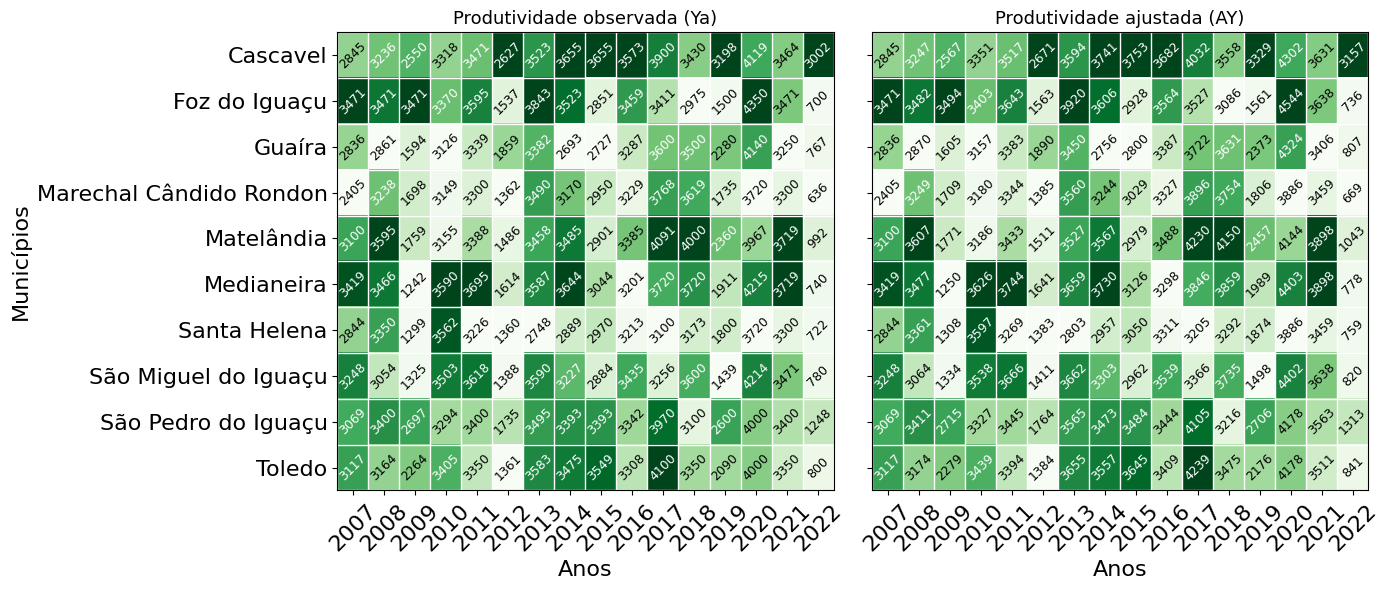

In [43]:
# ==========================
# MATRIZES
# ==========================
heatmap_ya = df_long.pivot(index='Localidade', columns='Ano', values='Ya')
heatmap_ay = df_long.pivot(index='Localidade', columns='Ano', values='AY')

heatmap_ya = heatmap_ya.sort_index()
heatmap_ay = heatmap_ay.loc[heatmap_ya.index]

# Converter para float + tratar NaN
heatmap_ya = heatmap_ya.astype(float)
heatmap_ay = heatmap_ay.astype(float)

# ==========================
# CONFIG
# ==========================
mats = [heatmap_ya, heatmap_ay]
titles = ["Produtividade observada (Ya)", "Produtividade ajustada (AY)"]

# ==========================
# FIGURA
# ==========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, df_mat, title in zip(axes, mats, titles):

    mat = df_mat.values

    # ==========================
    # NORMALIZAÇÃO SEGURA
    # ==========================
    mat_norm = np.zeros_like(mat)

    for col in range(mat.shape[1]):
        col_data = mat[:, col]

        # ignorar NaN
        vmin = np.nanmin(col_data)
        vmax = np.nanmax(col_data)

        if np.isnan(vmin) or np.isnan(vmax) or vmax == vmin:
            mat_norm[:, col] = 0.5
        else:
            mat_norm[:, col] = (col_data - vmin) / (vmax - vmin)

    # ==========================
    # PLOT
    # ==========================
    im = ax.imshow(mat_norm, cmap="Greens", aspect="auto")

    ax.set_title(title, fontsize=13)

    # ==========================
    # TEXTO NAS CÉLULAS
    # ==========================
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):

            val = mat[i, j]

            if np.isnan(val):
                continue

            color = "black" if mat_norm[i, j] < 0.5 else "white"

            ax.text(
                j, i,
                f"{val:.0f}",
                ha="center",
                va="center",
                color=color,
                fontsize=9,
                rotation=45,
                rotation_mode='anchor'
            )

    # ==========================
    # EIXOS
    # ==========================
    ax.set_xticks(np.arange(df_mat.shape[1]))
    ax.set_xticklabels(df_mat.columns.astype(int), rotation=45)

    ax.set_yticks(np.arange(df_mat.shape[0]))
    ax.set_yticklabels(df_mat.index)

    ax.set_xlabel("Ano")

# Y
axes[0].set_ylabel("Municípios", fontsize = 16)
axes[1].set_ylabel("")

axes[0].set_xlabel("Anos", fontsize = 16)
axes[1].set_xlabel("Anos", fontsize = 16)

# X
axes[0].tick_params(axis='y', labelsize=16)
axes[0].tick_params(axis='x', labelsize=16)
axes[1].tick_params(axis='x', labelsize=16)
# ==========================
# GRID
# ==========================
for ax in axes:
    for i in range(len(heatmap_ya.index) + 1):
        ax.axhline(i - 0.5, color='white', linewidth=1)
    for j in range(len(heatmap_ya.columns) + 1):
        ax.axvline(j - 0.5, color='white', linewidth=1)

plt.tight_layout()
plt.show()